In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


In [5]:
import pandas as pd

# Path from kagglehub
path = "/kaggle/input/heart-disease-dataset/heart.csv"

# Load dataset
df = pd.read_csv(path)
print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [9]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [10]:
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)
#convert categories to one hot encoded

<Axes: xlabel='sex', ylabel='target'>

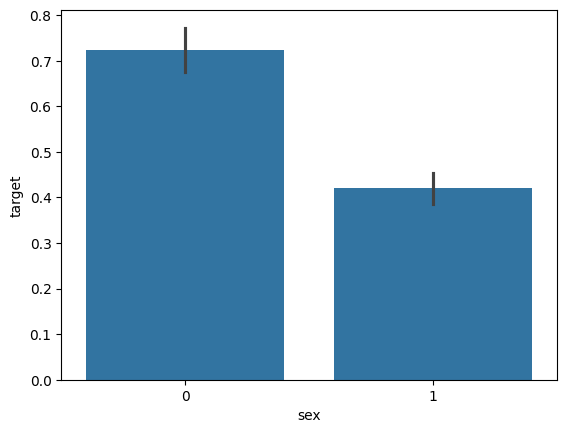

In [11]:
#eda
import seaborn as sns
sns.barplot(x='sex', y='target', data=df)

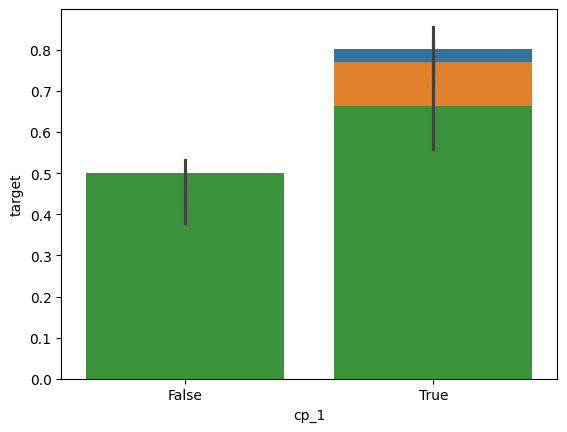

In [13]:
for col in ['cp_1', 'cp_2', 'cp_3']:
    sns.barplot(x=col, y='target', data=df)
#Do your EDA (visualizations) before one‑hot encoding — it’s easier to interpret categorical relationships in their original form.

<Axes: xlabel='age', ylabel='chol'>

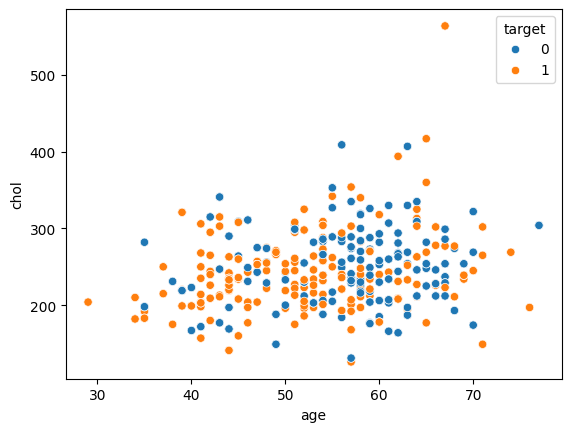

In [14]:
sns.scatterplot(x='age', y='chol', hue='target', data=df)

In [15]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age', 'trestbps','chol','thalach','oldpeak'] ] = scaler.fit_transform(df[['age','trestbps','chol','thalach','oldpeak']])

In [16]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,-0.268437,1,-0.377636,-0.659332,0,0.821321,0,-0.060888,2,0,False,False,False,True,False,False,True,False,False,True
1,-0.158157,1,0.479107,-0.833861,1,0.255968,1,1.727137,0,0,False,False,False,False,False,False,False,False,False,True
2,1.716595,1,0.764688,-1.396233,0,-1.048692,1,1.301417,0,0,False,False,False,True,False,False,False,False,False,True
3,0.724079,1,0.936037,-0.833861,0,0.516900,0,-0.912329,1,0,False,False,False,True,False,False,True,False,False,True
4,0.834359,0,0.364875,0.930822,1,-1.874977,0,0.705408,3,0,False,False,False,True,False,True,False,False,True,False


In [18]:
from sklearn.model_selection import train_test_split
X=df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [23]:
from sklearn.ensemble import RandomForestClassifier
model =   RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [24]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.80      0.86       102
           1       0.83      0.94      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205



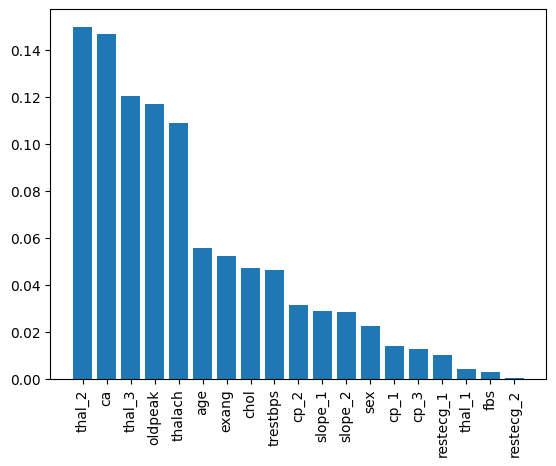

In [25]:
import matplotlib.pyplot as plt
import numpy as np
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()


In [26]:
# Check training accuracy
print("Training accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))


Training accuracy: 0.948780487804878
Test accuracy: 0.8731707317073171


In [27]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())


Cross-validation accuracy: 0.9043902439024392
